In [35]:
""" Read "Supplementary_table.xlsx" to analyze and graph."""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
file_path = "Supplementary_table3.xlsx"
data_full = pd.read_excel(file_path)

# Show table for structure
data_full

,Drugname,Time,Filename,Aver_pbody_number,Std_pbody_number,ROI_intensity,Background_intensity,Intensity (A. U),Std_intensity (A. U),Plate
0,DMSO,T1,W0082F0001T0001Z000C3.tif,51.454545,3.917117,143.233178,108.092923,35.140255,0.361983,1
1,DMSO,T1,W0082F0002T0001Z000C3.tif,58.792453,NaN,144.884054,109.054265,35.829790,NaN,1
2,DMSO,T1,W0082F0003T0001Z000C3.tif,57.500000,NaN,143.449321,108.155352,35.293969,NaN,1
3,DMSO,T1,W0082F0001T0001Z000C3.tif,43.714286,1.671237,139.778996,108.170856,31.608140,2.462008,2
4,DMSO,T1,W0082F0002T0001Z000C3.tif,46.202247,NaN,139.905084,108.767039,31.138046,NaN,2
...,...,...,...,...,...,...,...,...,...,...
7147,TQ0319,T7,W0042F0002T0007Z000C3.tif,37.476190,NaN,127.070554,107.993671,19.076883,NaN,5
7148,TQ0319,T7,W0042F0003T0007Z000C3.tif,38.411765,NaN,126.677896,109.770349,16.907547,NaN,5
7149,TQ0319,T8,W0042F0001T0008Z000C3.tif,41.488889,0.149064,124.558673,110.346871,14.211802,2.232944,5
7150,TQ0319,T8,W0042F0002T0008Z000C3.tif,41.428571,NaN,126.636953,108.049902,18.587051,NaN,5


In [36]:
print(data_full[data_full["Drugname"]=="DMSO"][["Time", "Aver_pbody_number"]])

    Time  Aver_pbody_number
0     T1          51.454545
1     T1          58.792453
2     T1          57.500000
3     T1          43.714286
4     T1          46.202247
..   ...                ...
115   T8          46.314815
116   T8          44.970874
117   T8          50.940476
118   T8          43.261905
119   T8          56.756098

[120 rows x 2 columns]


In [37]:
""" Filter data so that only "Time" T6 is shown """
data = data_full[data_full["Time"] == "T6"]
data

,Drugname,Time,Filename,Aver_pbody_number,Std_pbody_number,ROI_intensity,Background_intensity,Intensity (A. U),Std_intensity (A. U),Plate
75,DMSO,T6,W0082F0001T0006Z000C3.tif,59.772727,3.281702,132.139314,109.149558,22.989756,2.941009,1
76,DMSO,T6,W0082F0002T0006Z000C3.tif,66.320755,NaN,137.457798,109.914386,27.543411,NaN,1
77,DMSO,T6,W0082F0003T0006Z000C3.tif,62.657895,NaN,137.236989,108.746004,28.490985,NaN,1
78,DMSO,T6,W0082F0001T0006Z000C3.tif,51.471429,2.216423,132.255019,111.112997,21.142022,1.818806,2
79,DMSO,T6,W0082F0002T0006Z000C3.tif,52.258427,NaN,134.069565,110.780155,23.289410,NaN,2
...,...,...,...,...,...,...,...,...,...,...
7120,TQ0277,T6,W0034F0002T0006Z000C3.tif,34.952381,NaN,136.676123,108.699390,27.976732,NaN,5
7121,TQ0277,T6,W0034F0003T0006Z000C3.tif,35.096154,NaN,139.549176,108.865062,30.684114,NaN,5
7143,TQ0319,T6,W0042F0001T0006Z000C3.tif,37.377778,1.989604,125.933716,109.774519,16.159198,1.771260,5
7144,TQ0319,T6,W0042F0002T0006Z000C3.tif,40.476190,NaN,127.220053,107.773393,19.446659,NaN,5


# Figure 1: # of Pbody Accross Time 

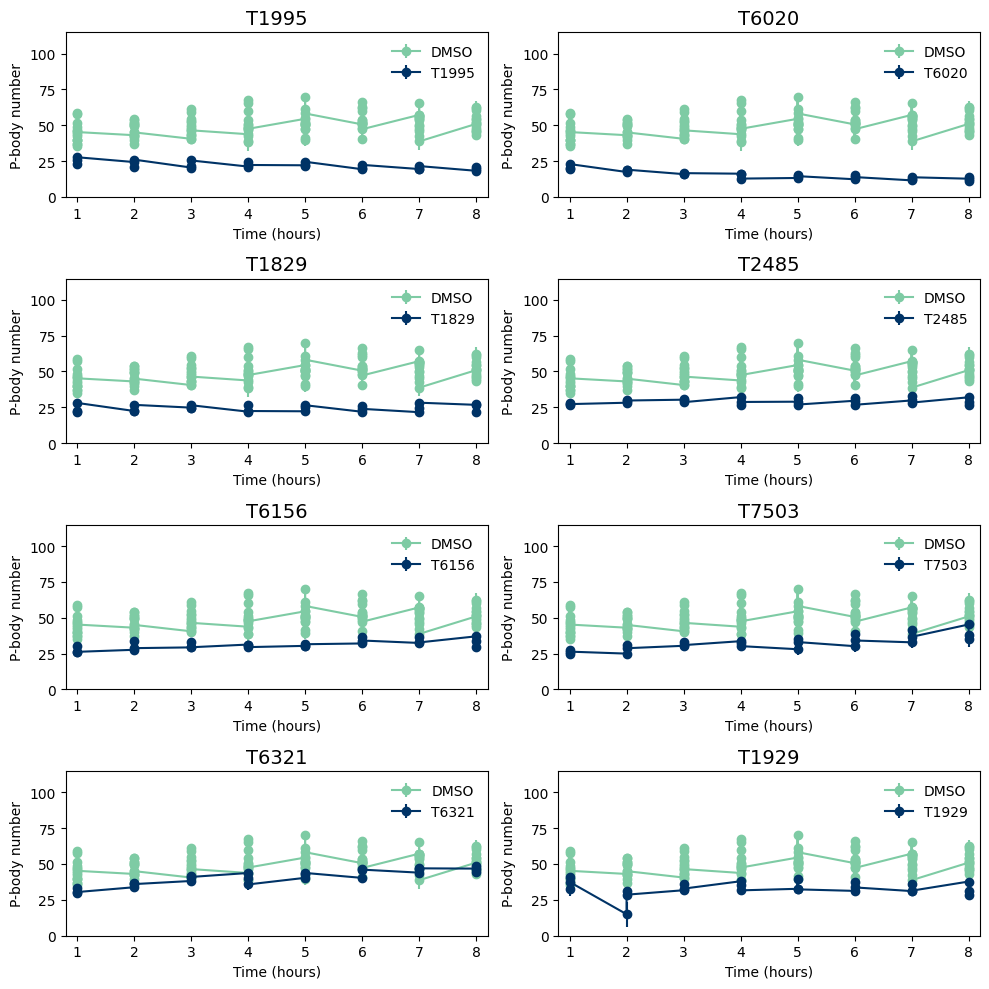

In [38]:
# --- FIX TIME COLUMN ---
data_full["Time"] = data_full["Time"].astype(str).str.replace("T","").astype(float)

# Drugs to include
drugs_to_plot = ["T1995", "T6020", "T1829", "T2485", 
                 "T6156", "T7503", "T6321", "T1929"]

# Get DMSO data_full once
dms = data_full[data_full["Drugname"]=="DMSO"].sort_values("Time")

if dms.empty:
    raise ValueError("No DMSO data_full found in table.")

# Create subplot grid
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
axes = axes.flatten()

for i, drug in enumerate(drugs_to_plot):
    ax = axes[i]

    sub = data_full[data_full["Drugname"]==drug].sort_values("Time")

    if sub.empty:
        ax.text(0.5, 0.5, f"{drug}\n(no data_full)", ha="ce-nter", va="center", fontsize=12)
        ax.axis("off")
        continue

    # DMSO curve
    ax.errorbar(
        dms["Time"], dms["Aver_pbody_number"],
        yerr=dms["Std_pbody_number"],
        fmt="-o", color="#7ECBA4", label="DMSO"
    )

    # Drug curve
    ax.errorbar(
        sub["Time"], sub["Aver_pbody_number"],
        yerr=sub["Std_pbody_number"],
        fmt="-o", color="#003366", label=drug
    )

    # Styling
    ax.set_title(f"{drug}", fontsize=14)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("P-body number")
    ax.set_ylim(0, 1.3 * data_full["Aver_pbody_number"].max())
    ax.set_xlim(data_full["Time"].min() - 0.2, data_full["Time"].max() + 0.2)

    ax.legend(frameon=False, fontsize=10)

# Remove empty subplot frames if any remain
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("figure1_all_subplots.png", dpi=300)
plt.show()


# Figure 2: Groups and Intensity/Pbody #

In [40]:
group_dict = {
    "G1": ["T0374","TD374L","T1912","T1995","T6020","T7394"],
    "G2": ["T0860","T1448","T1656","T2508","T2509","T3380"],
    "G3": ["T0801","T1829","T2485","T2677","T6156","T7503"],
    "G4": ["T1929","T4883","T1936","T5171","T2S0007","T5177",
           "T3211","T6321","T3269","T7486","T3603","T7861",
           "T3616","T8482"],
    "G5": ["T12594","T1791","T1791L","T2372","T6165","T6588",
           "T6758","T7604","T8387"]
}

In [41]:
data_full["Time"] = data_full["Time"].astype(str).str.replace("T","").astype(float)

In [42]:
# Calculate intensity ratio
data["Intensity_ratio"] = data["Intensity (A. U)"] / data["Aver_pbody_number"]

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_11308/3017998177.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Intensity_ratio"] = data["Intensity (A. U)"] / data["Aver_pbody_number"]


In [43]:
# Helper function to separate by groups
def assign_group(drug):
    for g, items in group_dict.items():
        if drug in items:
            return g
    if drug == "DMSO":
        return "DMSO"
    return None  # ignore drugs not in groups

data["Group"] = data["Drugname"].apply(assign_group)
data = data[data["Group"].notna()]


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_11308/479396348.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Group"] = data["Drugname"].apply(assign_group)


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_11308/944291971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


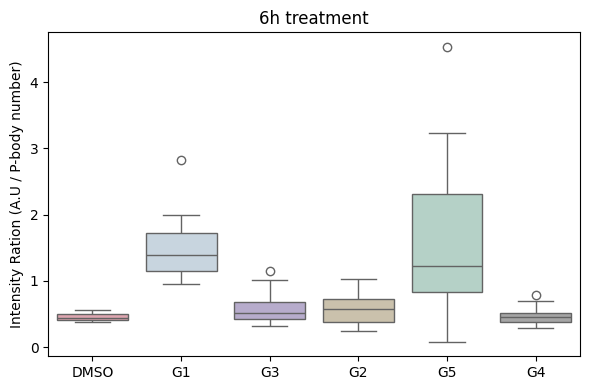

In [46]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data= data,
    x="Group",
    y="Intensity_ratio",
    palette=["#E89BAA","#C4D6E3","#B5A7D1","#CFC3A7","#B0D6C8","#A5A5A5"]
)

plt.ylabel("Intensity Ration (A.U / P-body number)")
plt.xlabel("")
plt.title("6h treatment")

plt.tight_layout()
plt.savefig("figure2_groups_boxplot.png", dpi=300)
plt.show()